In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
import cmath
from scipy.integrate import odeint

In [5]:
def theta_dot(theta,t,N,omega,K):
    sin_term = 0
    for i in range(N):
        sin_term += np.sin(np.roll(theta,i)-theta) #produces sin term for all theta_i
    return omega + (K/N)*sin_term #produces all theta_dot_i terms

#Initial Conditions
n = 550
T = 60
t = np.linspace(0,T,n)
K = 4
kappa = [K]
theta0 = np.array([0,1,2,3])
omega0 = np.array([6,5,4,3])
N = len(theta0)
ts = []
thetas = np.ones(4)
omegas = np.ones(4)
rs=[]
psis=[]

theta_solved = odeint(theta_dot,theta0,t,args=(N,omega0,K))

#Isolate metronome data into their own arrays
for i in range(n):
    thetas = np.vstack((thetas,theta_solved[i]))
thetas = np.delete(thetas,(0),axis=0).T

#Make r and psi data
for i in range(n):
    z = (1/N)*np.sum(np.exp(1j*thetas.T[i]))
    r = np.abs(z)
    psi = cmath.phase(z)
    rs.append(r)
    psis.append(psi)

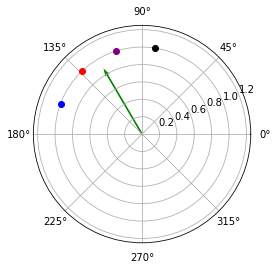

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), subplot_kw={'projection': 'polar'})# layout='constrained')
ax.quiver(0,0,psis[14],rs[14], color='green', scale_units='xy',angles='xy',scale=1)
ax.plot(thetas[0][14], np.ones(len(t))[1], color='blue', label='original', marker='o')
ax.plot(thetas[1][14], np.ones(len(t))[1], color='red', label='original', marker='o')
ax.plot(thetas[2][14], np.ones(len(t))[1], color='purple', label='original', marker='o')
ax.plot(thetas[3][14], np.ones(len(t))[1], color='black', label='original', marker='o')
ax.set_rmax(1.25)

In [6]:
#In frame of plot (all points and r are moving)
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5), subplot_kw={'projection': 'polar'})# layout='constrained')

def animate(i):
    ax.clear()
    # Plot that point using the x and y coordinates
    ax.quiver(np.zeros(len(t))[i], np.zeros(len(t))[i], psis[i], rs[i], color='green', scale_units='xy',angles='xy',scale=1) #NEED TO SCALE ARROW NEXT
    ax.plot(thetas[0][i], np.ones(len(t))[i], color='blue', label='original', marker='o')
    ax.plot(thetas[1][i], np.ones(len(t))[i], color='red', label='original', marker='o')
    ax.plot(thetas[2][i], np.ones(len(t))[i], color='purple', label='original', marker='o')
    ax.plot(thetas[3][i], np.ones(len(t))[i], color='black', label='original', marker='o')
    ax.set_rmax(1.25)
ani = FuncAnimation(fig, animate, frames=len(t),
                    interval=500, repeat=False)
plt.close()

In [7]:
# Save the animation as an animated dd
ani.save("ode_kappa=%s.gif"%kappa[0], dpi=300,
         writer=PillowWriter(fps=5))

In [8]:
#In frame of r (only points are moving)
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5), subplot_kw={'projection': 'polar'})# layout='constrained')

def animate(i):
    ax.clear()
    # Plot that point using the x and y coordinates
    ax.quiver(np.zeros(len(t))[i], np.zeros(len(t))[i], np.zeros(len(t))[i], rs[i], color='green', scale_units='xy',angles='xy',scale=1) #NEED TO SCALE ARROW NEXT
    ax.plot(thetas[0][i]-psis[i], np.ones(len(t))[i], color='blue', label='original', marker='o')
    ax.plot(thetas[1][i]-psis[i], np.ones(len(t))[i], color='red', label='original', marker='o')
    ax.plot(thetas[2][i]-psis[i], np.ones(len(t))[i], color='purple', label='original', marker='o')
    ax.plot(thetas[3][i]-psis[i], np.ones(len(t))[i], color='black', label='original', marker='o')
    ax.set_rmax(1.25)
ani = FuncAnimation(fig, animate, frames=len(t),
                    interval=500, repeat=False)
plt.close()

In [9]:
# Save the animation as an animated dd
ani.save("ode_rframe_kappa=%s.gif"%kappa[0], dpi=300,
         writer=PillowWriter(fps=5))